In [2]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    sys.path.append(str(dir))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import torch
from pathlib import Path
from nn import Unet1D
from config import Config
from utils import posterior_beta, log_transform, inverse_standard, compute_aic_log_likelihood, one_step_rolling_forecast, compute_aic_log_likelihood_stdresid, load_and_split_snp500, test_stationarity, plot_distribution
from diffusion import reverse
import time
import yfinance as yf
import math
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf, adfuller
from numpy.lib.stride_tricks import sliding_window_view
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from arch import arch_model
import joblib
import random

In [4]:
rng = np.random.default_rng()

In [5]:
window = 256
data = load_and_split_snp500(window, transform_fn=log_transform)

In [6]:
train_snp500 = data["train"]
len(train_snp500)

2413

In [7]:
SYN_PATH = dir / "data" / "syn_data_256.joblib"
synthetic_data_all = joblib.load(SYN_PATH)

In [8]:
stride = window

empirical_window = []
for i in range(0, len(train_snp500) - window + 1, stride):
    empirical_window.append(train_snp500[i:i+window])

empirical_window = np.array(empirical_window)

In [9]:
synthetic_data = rng.choice(synthetic_data_all, size=len(empirical_window), axis=0, replace=False)

### Normal Plot

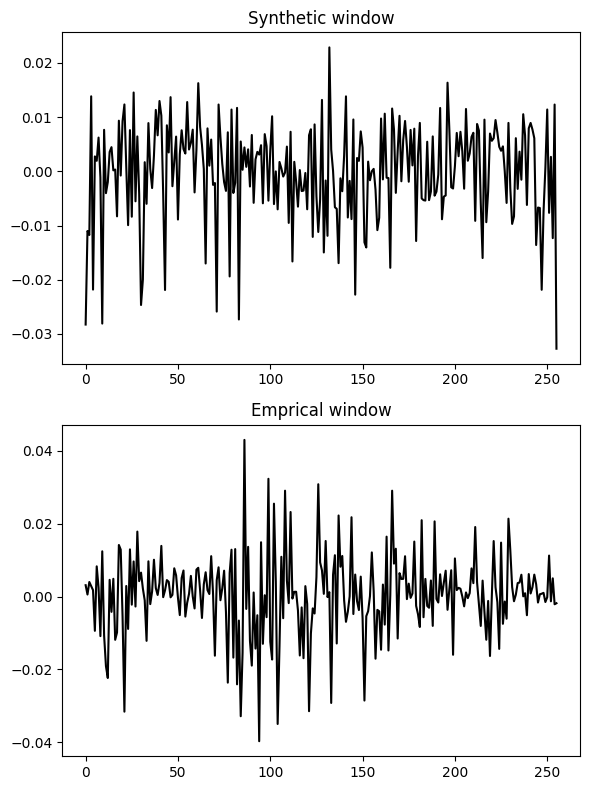

In [9]:
"""
  Note that the generated synthetic window cant be indexed by time since it doesnt preserve time index.
  We would label it as what a typical n-window return looked like from the training data.
"""

fig, ax = plt.subplots(figsize=(6, 8), nrows=2)

ax[0].plot(synthetic_data[0], c="black")
ax[1].plot(empirical_window[0], c="black")
ax[0].set_title("Synthetic window")
ax[1].set_title("Emprical window")

fig.tight_layout()
plt.show()

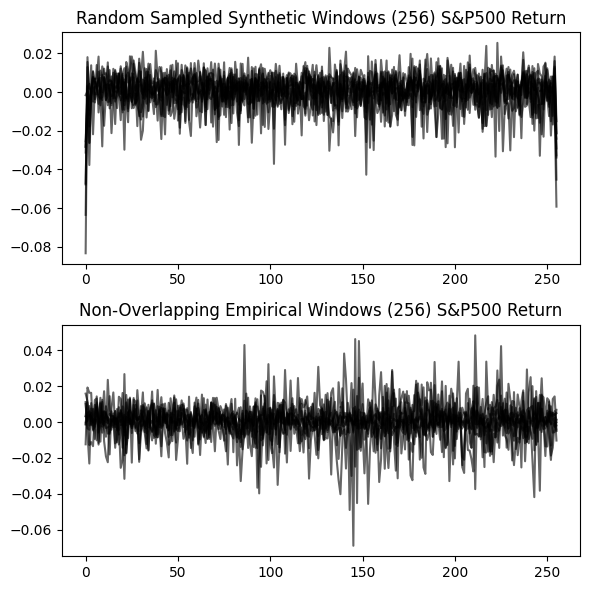

In [10]:
fig, ax = plt.subplots(figsize=(6, 6), nrows=2)
for i in range(len(synthetic_data)):
  ax[0].plot(synthetic_data[i], alpha=0.6, c="black")

ax[0].set_title(f"Random Sampled Synthetic Windows ({window}) S&P500 Return")

for i in range(len(empirical_window)):
  ax[1].plot(empirical_window[i], alpha=0.6, c="black")

ax[1].set_title(f"Non-Overlapping Empirical Windows ({window}) S&P500 Return")

fig.tight_layout()
plt.show()

### Stationarity Tests

In [11]:
adf_emp = test_stationarity(empirical_window)
adf_syn = test_stationarity(synthetic_data)

In [12]:
rejections_1_syn = 0
rejections_5_syn = 0
rejections_10_syn = 0

rejections_1_emp = 0
rejections_5_emp = 0
rejections_10_emp = 0

for idx, res in enumerate(adf_syn):
  p_value = res[1]

  if p_value < 0.01:
    rejections_1_syn += 1
  if p_value < 0.05:
      rejections_5_syn += 1
  if p_value < 0.10:
      rejections_10_syn += 1

for idx, res in enumerate(adf_emp):
  p_value = res[1]

  if p_value < 0.01:
    rejections_1_emp += 1
  if p_value < 0.05:
      rejections_5_emp += 1
  if p_value < 0.10:
      rejections_10_emp += 1

In [13]:
print("Synthetic")
print(f"Rejection rate p-value(0.01) : {rejections_1_syn / len(adf_syn):.2f}")
print(f"Rejection rate p-value(0.05) : {rejections_5_syn / len(adf_syn):.2f}")
print(f"Rejection rate p-value(0.10) : {rejections_10_syn / len(adf_syn):.2f}")
print("="*50)

print("Empirical")
print(f"Rejection rate p-value(0.01) : {rejections_1_emp / len(adf_emp):.2f}")
print(f"Rejection rate p-value(0.05) : {rejections_5_emp / len(adf_emp):.2f}")
print(f"Rejection rate p-value(0.10) : {rejections_10_emp / len(adf_emp):.2f}")

Synthetic
Rejection rate p-value(0.01) : 1.00
Rejection rate p-value(0.05) : 1.00
Rejection rate p-value(0.10) : 1.00
Empirical
Rejection rate p-value(0.01) : 1.00
Rejection rate p-value(0.05) : 1.00
Rejection rate p-value(0.10) : 1.00


### Theoretical Distribution Comparison  

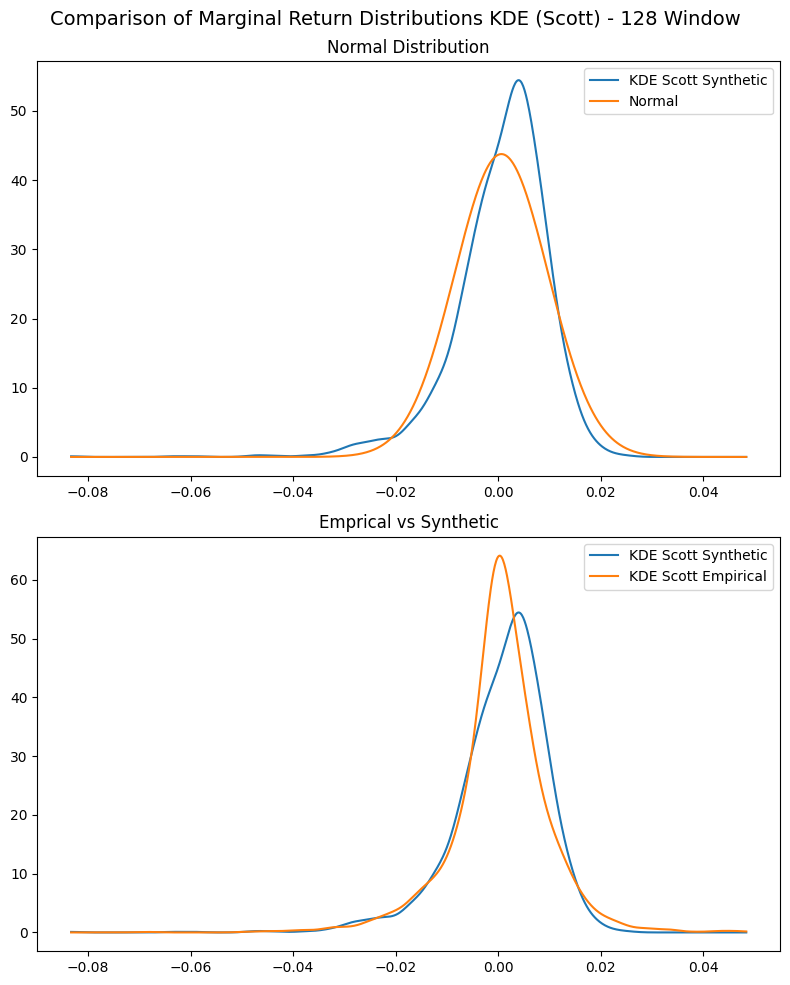

In [14]:
plot_distribution(synthetic_data, empirical_window)

### Log-Likelihood AIC Comparison

In [15]:
emp_len = len(empirical_window)
t_wins_emp, norm_wins_emp, _ = compute_aic_log_likelihood(empirical_window)

print(f"T rate : ", t_wins_emp / emp_len)
print(f"Norm rate : ", norm_wins_emp / emp_len)

T rate :  1.0
Norm rate :  0.0


In [16]:
syn_len = len(empirical_window)
t_rates = []
norm_rates = []

for i in range(1000):
  synthetic_data_rnd = rng.choice(synthetic_data_all, size=syn_len, axis=0, replace=False)

  t_wins_syn, norm_wins_syn, _ = compute_aic_log_likelihood(synthetic_data_rnd)
  t_rate = t_wins_syn / syn_len
  norm_rate = norm_wins_syn / syn_len
  t_rates.append(t_rate)
  norm_rates.append(norm_rate)

t_rates = np.array(t_rates)
norm_rates = np.array(norm_rates)

In [17]:
print("Mean t-rate:", t_rates.mean())
print("Std t-rate:", t_rates.std())
print("Mean norm-rate:", norm_rates.mean())
print("Std norm-rate:", norm_rates.std())

Mean t-rate: 0.9877777777777779
Std t-rate: 0.036497928234792996
Mean norm-rate: 0.012222222222222221
Std norm-rate: 0.03649792823479298


### QQ Plots

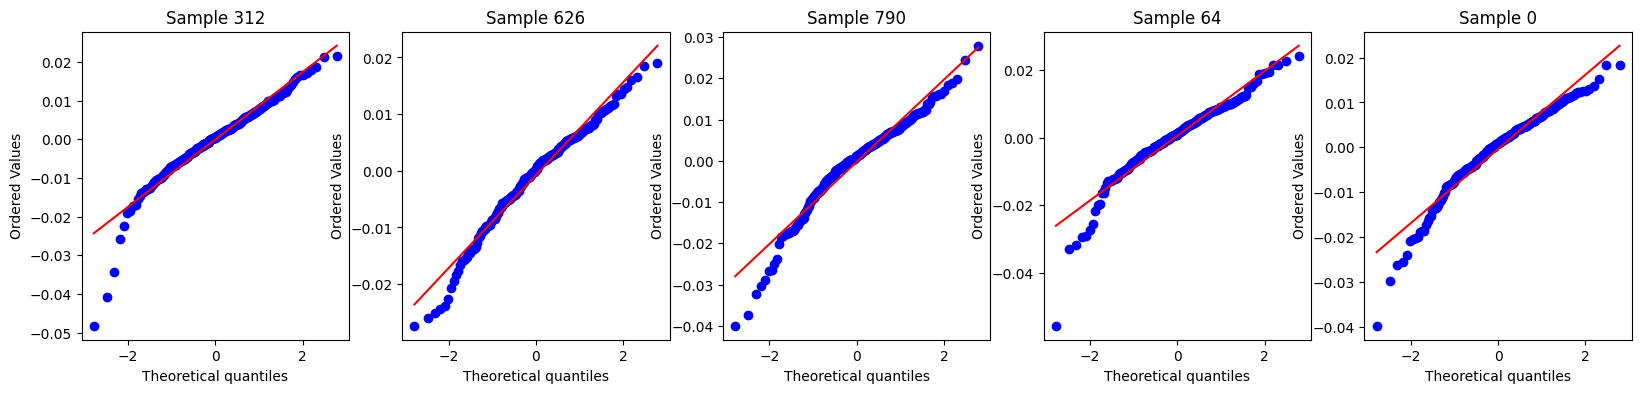

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(synthetic_data_all), 5, replace=False)

for ax, i in zip(axes, indices):
    stats.probplot(synthetic_data_all[i], dist="norm", plot=ax)
    ax.set_title(f"Sample {i}")

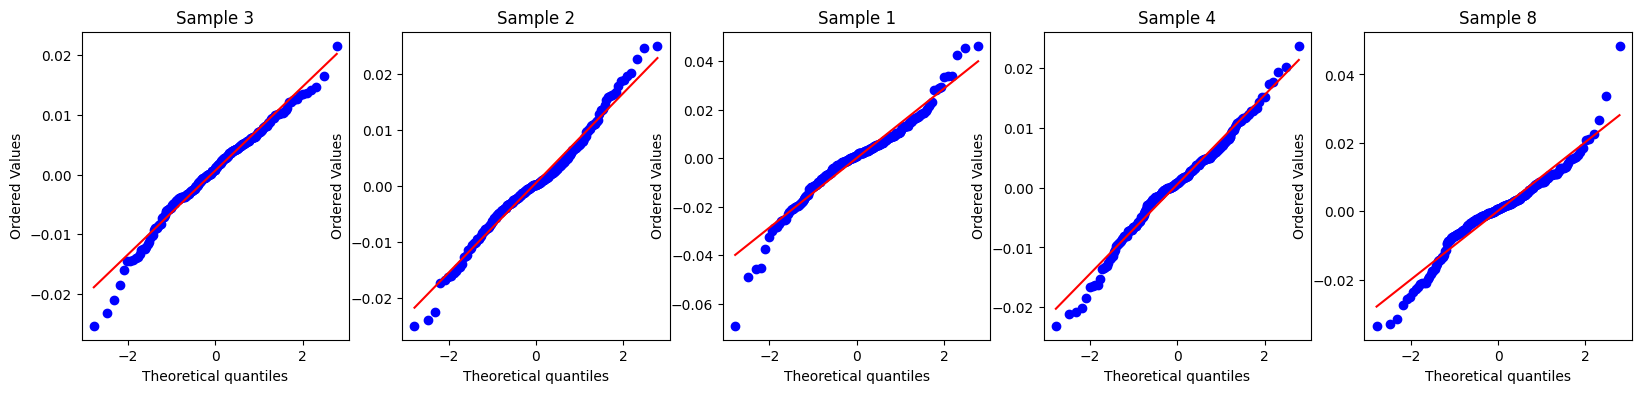

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(empirical_window), 5, replace=False)

for ax, i in zip(axes, indices):
    stats.probplot(empirical_window[i], dist="norm", plot=ax)
    ax.set_title(f"Sample {i}")

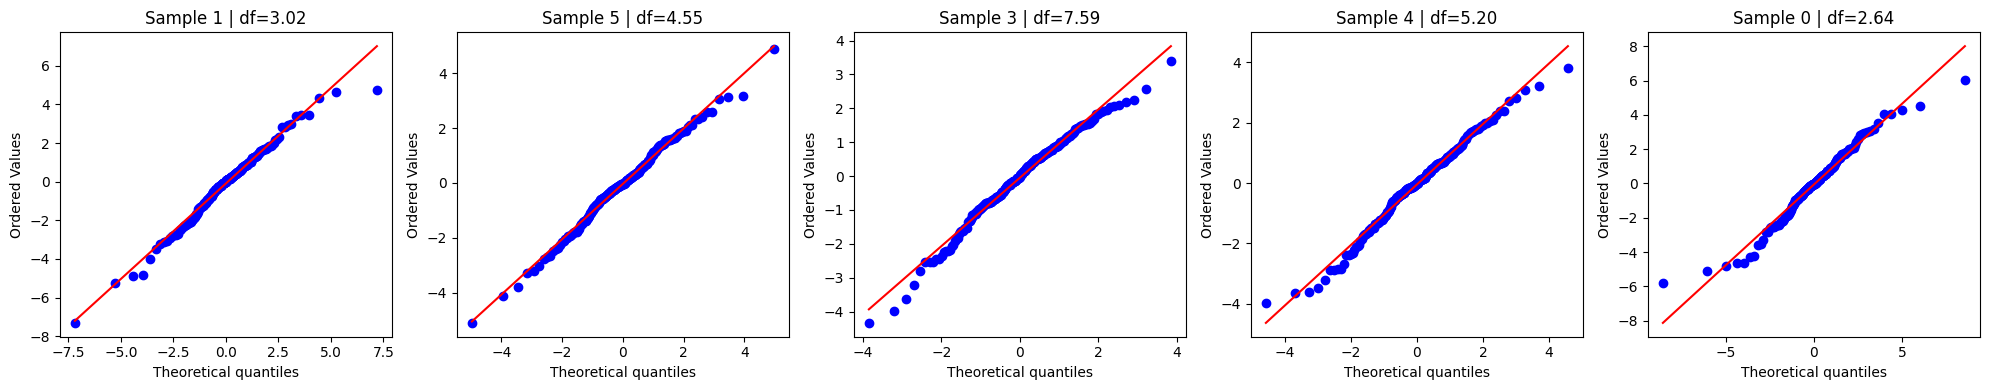

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(empirical_window), 5, replace=False)

for ax, i in zip(axes, indices):
    sample = empirical_window[i]

    df, loc, scale = stats.t.fit(sample)

    standardized = (sample - loc) / scale

    stats.probplot(
        standardized,
        dist=stats.t,
        sparams=(df,),
        plot=ax
    )

    ax.set_title(f"Sample {i} | df={df:.2f}")

plt.tight_layout()
plt.show()

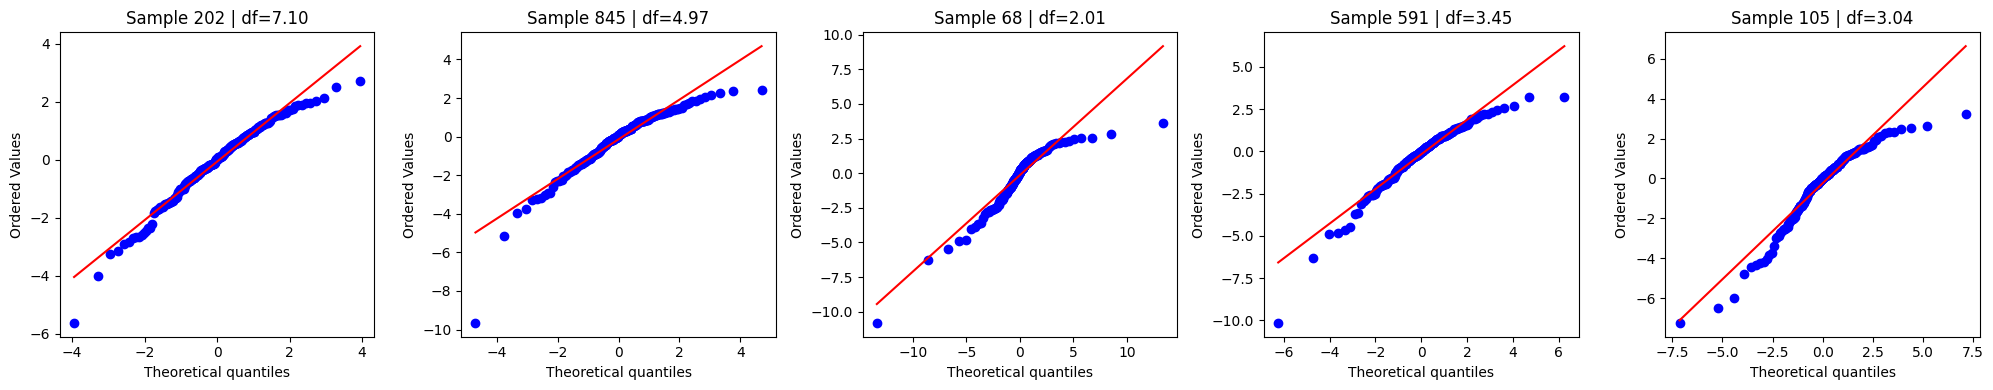

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(synthetic_data_all), 5, replace=False)

for ax, i in zip(axes, indices):
  sample = synthetic_data_all[i]

  df, loc, scale = stats.t.fit(sample)

  standardized = (sample - loc) / scale

  stats.probplot(
      standardized,
      dist=stats.t,
      sparams=(df,),
      plot=ax
  )

  ax.set_title(f"Sample {i} | df={df:.2f}")

plt.tight_layout()
plt.show()

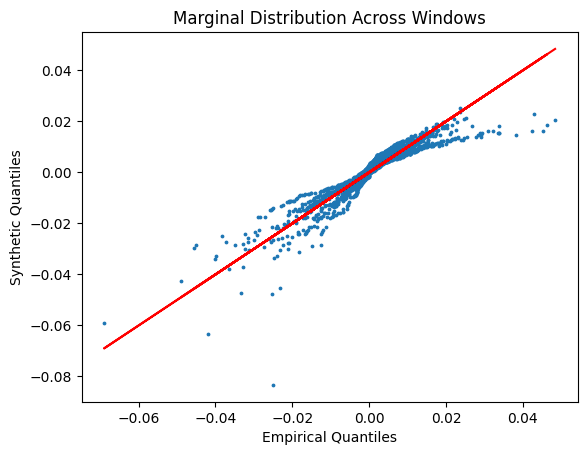

In [22]:
x = np.sort(empirical_window)
y = np.sort(synthetic_data)

plt.scatter(x, y, s=3)
plt.plot(x, x, color='red') # reference target
plt.xlabel("Empirical Quantiles")
plt.ylabel("Synthetic Quantiles")
plt.title("Marginal Distribution Across Windows")
plt.show()

In [23]:
kurtosis_emp = stats.kurtosis(empirical_window.reshape(-1))
skew_emp = stats.skew(empirical_window.reshape(-1))
kurtosis_syn = stats.kurtosis(synthetic_data.reshape(-1))
skew_syn = stats.skew(synthetic_data.reshape(-1))

print("="*10 + "Empirical" + "="*10)
print(f"Kurtosis : {kurtosis_emp}\nSkewness : {skew_emp}")

print("="*10 + "Synthetic" + "="*10)
print(f"Kurtosis : {kurtosis_syn}\nSkewness : {skew_syn}")

==========Empirical==========
Kurtosis : 4.584840460148701
Skewness : -0.47061797986958415
==========Synthetic==========
Kurtosis : 6.633958749794564
Skewness : -1.5289115371189475


## Intra-Window Evaluation

In [24]:
lags=10

In [25]:
def compute_acf_matrix(windows, lags):
  return np.array([
      acf(w, nlags=lags, fft=True)
      for w in windows
  ])

def compute_ljung(windows, p_lag):
  """
    Returns:
    1. rejection_rate: rejection rate across windows
  """
  rejection_rate = 0

  for window in windows:
    res = sm.stats.acorr_ljungbox(window, lags=p_lag)
    lb_pvalue = res["lb_pvalue"].iloc[-1]
    rejection_rate += 1 if lb_pvalue < 0.05 else False

  return rejection_rate / len(windows)

def compare_acf_matrix(lag, acf_matrix):
  acf_value = acf_matrix[1:, lag]
  return np.mean(acf_value), np.std(acf_value)  

def compare_acf_matrices(lag, m1, m2):
  acf_m1 = m1[:, lag]
  acf_m2 = m2[:, lag]

  acf_m1_std = np.std(acf_m1)
  acf_m2_std = np.std(acf_m2)

  acf_m1_mean = np.mean(acf_m1)
  acf_m2_mean = np.mean(acf_m2)

  acf_m1_percentiles = np.percentile(m1[1:, lag], [25, 50, 75])
  acf_m2_percentiles = np.percentile(m2[1:, lag], [25, 50, 75])

  return {
    "m1_std": acf_m1_std,
    "m2_std": acf_m2_std,
    "m1_mean": acf_m1_mean,
    "m2_mean": acf_m2_mean,
    "m1_percentiles": acf_m1_percentiles,
    "m2_percentiles": acf_m2_percentiles,
  }

In [26]:
SAMPLES = 1000
LAGS = 10
syn_reject_rate_list = []
rng = np.random.default_rng()

for i in range(SAMPLES):
  syn_sampled_window = rng.choice(synthetic_data_all, size=len(empirical_window), replace=False, axis=0)
  syn_rejection_rate = compute_ljung(syn_sampled_window, p_lag=LAGS)
  syn_reject_rate_list.append(syn_rejection_rate)

emp_reject_rate = compute_ljung(empirical_window, p_lag=LAGS)
syn_reject_std = np.std(syn_reject_rate_list)
syn_reject_mean = np.mean(syn_reject_rate_list)

In [27]:
print(f"Empirical rejection rate: ", emp_reject_rate)
print(f"Synthetic rejection rate mean: ", syn_reject_mean)
print(f"Synthetic rejection rate std: ", syn_reject_std)

Empirical rejection rate:  0.2222222222222222
Synthetic rejection rate mean:  0.3391111111111111
Synthetic rejection rate std:  0.15742119329609158


In [28]:
acf_emp = compute_acf_matrix(empirical_window, lags)
acf_syn = compute_acf_matrix(synthetic_data[:5], lags)

Figure(640x480)


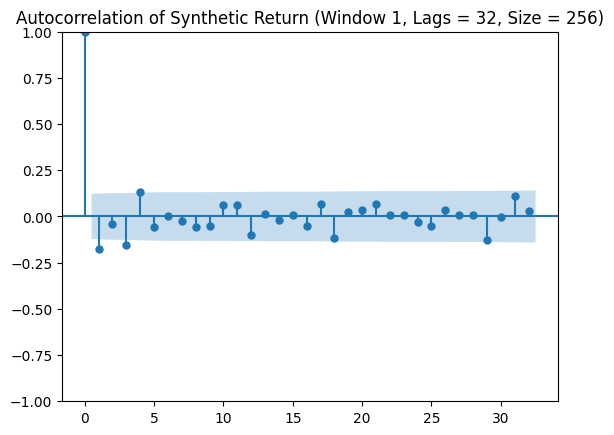

In [29]:
print(plot_acf(synthetic_data[1], lags=32, title="Autocorrelation of Synthetic Return (Window 1, Lags = 32, Size = 256)"))

Figure(640x480)


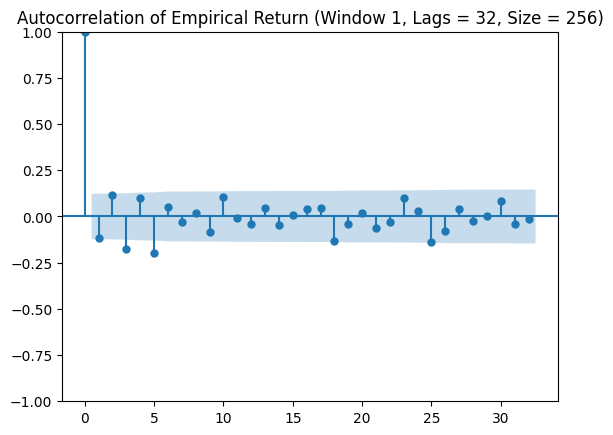

In [30]:
print(plot_acf(empirical_window[1], lags=32, title="Autocorrelation of Empirical Return (Window 1, Lags = 32, Size = 256)"))

In [31]:
def get_residuals(window, lags=1):
    model = AutoReg(window, lags=lags, old_names=False).fit()
    return model.resid

# compute AR(1)
res_emp = np.array([get_residuals(w) for w in empirical_window])
res_syn = np.array([get_residuals(w) for w in synthetic_data_all])

def arch_test(residuals, ddof):
    _, pval, _, _ = sm.stats.diagnostic.het_arch(residuals, ddof=ddof, nlags=10)
    return pval

# ddof = 2 because the residuals comes from regression model which have lag =1 and intercept 1 = 2
# Or common seeting for ddof = p + q for ARMA(p, q)
arch_emp = [arch_test(r, 2) for r in res_emp]

syn_arch_rejection_list = []
for i in range(1000):
  res_sampled = rng.choice(res_syn, size=len(res_emp), replace=False, axis=0)
  arch_syn_samples = [arch_test(r, 2) for r in res_sampled]
  
  rejection = sum(p_value < 0.05 for p_value in arch_syn_samples)
  syn_arch_rejection_list.append(rejection / len(arch_syn_samples))

emp_arch_rejection_rate = sum(p_value < 0.05 for p_value in arch_emp) / len(arch_emp)
syn_arch_rejection_list = np.array(syn_arch_rejection_list)

In [32]:
emp_arch_rejection_rate

np.float64(0.7777777777777778)

In [33]:
standard_error = syn_arch_rejection_list.std() / np.sqrt(100)

print("Syn LM-ARCH Tests Rejection Rate Mean : ", syn_arch_rejection_list.mean())
print("Syn LM-ARCH Tests Rejection Rate STD : ", syn_arch_rejection_list.std())
print("Syn LM-ARCH Tests Rejection Rate Standard Error : ", standard_error)

Syn LM-ARCH Tests Rejection Rate Mean :  0.09100000000000001
Syn LM-ARCH Tests Rejection Rate STD :  0.09337558567420072
Syn LM-ARCH Tests Rejection Rate Standard Error :  0.009337558567420072


In [34]:
res_squared_emp = res_emp ** 2
res_squared_syn = res_syn ** 2

Figure(640x480)


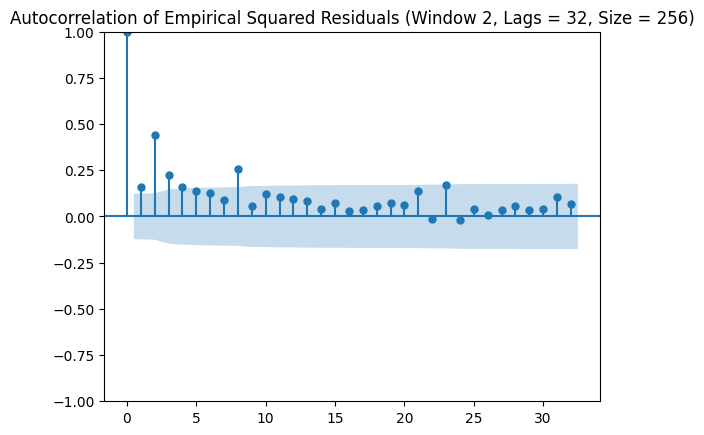

In [99]:
print(plot_acf(res_squared_emp[1], lags=32, title="Autocorrelation of Empirical Squared Residuals (Window 2, Lags = 32, Size = 256)"))

Figure(640x480)


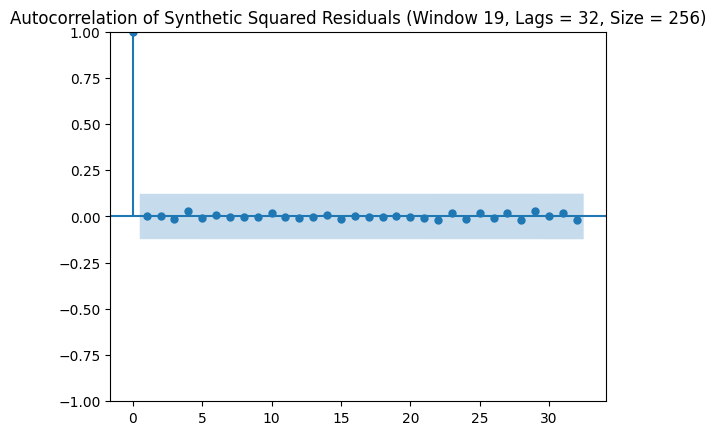

In [ ]:
print(plot_acf(res_squared_syn[], lags=32, title="Autocorrelation of Synthetic Squared Residuals (Window 19, Lags = 32, Size = 256)"))

In [37]:
SAMPLES = 1000
LAGS = 10
syn_reject_rate_list = []
rng = np.random.default_rng()

for i in range(SAMPLES):
  syn_sampled_squared_res = rng.choice(res_squared_syn, size=len(res_squared_emp), replace=False, axis=0)
  syn_rejection_rate = compute_ljung(syn_sampled_squared_res, p_lag=LAGS)
  syn_reject_rate_list.append(syn_rejection_rate)

emp_reject_rate = compute_ljung(res_squared_emp, p_lag=LAGS)
syn_reject_std = np.std(syn_reject_rate_list)
syn_reject_mean = np.mean(syn_reject_rate_list)

In [38]:
print(f"Empirical rejection rate: ", emp_reject_rate)
print(f"Synthetic rejection rate mean: ", syn_reject_mean)
print(f"Synthetic rejection rate std: ", syn_reject_std)

Empirical rejection rate:  0.7777777777777778
Synthetic rejection rate mean:  0.052777777777777785
Synthetic rejection rate std:  0.07514389488356059


### Conclusion
1) The model generate stationarity fixed-window segment returns, which correlates with most financial return properties

2) Due to the small sample size (N=5) that leads to low statistical power, though conclusions are constrained by sample size. Given the computations of ljung box test rejection rate mean on repeated 5 random sampled windows, we could see that the rejection rate mean over-rejects compared to empirical windows tested on 10 lags. Both empirical and synthetic returns exhibit statistically significant autocorrelation as indicated by the Ljung–Box test. Also by the statistic comparion on mean, std, percentiles across windows within the same lag-p, it shows that although on overall ddpm captures the structure decay on the acf of returns, it overly misinterprets the scale magnitude of autocorrelation. Therefore, ddpm capture partial stylized facts.

3) Although the baseline model reproduces the general shape of the empirical return distribution, it fails to accurately capture the scale, as evidenced by deviations in the tails of the QQ plot as a marginal distribution comparison, suggesting an overestimation of extreme values

4) The ARCH test results, despite being based on a limited number of windows, indicate that volatility clustering is present in most empirical windows, supporting the use of GARCH-type models. In contrast, the synthetic data exhibits consistently stronger ARCH effects across all windows, suggesting that the model overestimates the strength and persistence of conditional heteroskedasticity.

### GARCH Evaluation under Fixed Window Segmentation

In [185]:
def compute_arch(windows, mean="zero", vol="GARCH", p=1, q=1, dist="t"):
  result = []
  n = len(windows)

  for i in range(n):
    model = arch_model(
      windows[i] * 100,
      mean=mean,
      vol=vol,
      p=p,
      q=q,
      dist=dist
    )

    res = model.fit(disp="off")
    result.append(res)

  return result

In [186]:
arch_emp = compute_arch(empirical_window)
arch_syn = compute_arch(synthetic_data_all)

In [187]:
rho_emp = np.array([
    res.params["alpha[1]"] + res.params["beta[1]"]
    for res in arch_emp
])

rho_syn_all = np.array([
    res.params["alpha[1]"] + res.params["beta[1]"]
    for res in arch_syn
])

metrics = []
rng = np.random.default_rng()

for _ in range(1000):
    idx = rng.choice(len(rho_syn_all), size=len(rho_emp), replace=False)
    rho_syn = rho_syn_all[idx]

    dist = stats.wasserstein_distance(rho_emp, rho_syn)
    metrics.append(dist)

Text(0.5, 1.0, 'Distribution of Distance (Empirical vs Synthetic)')

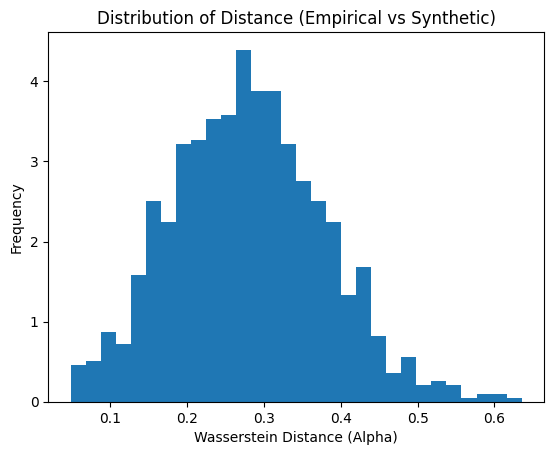

In [188]:
plt.hist(metrics, bins=30, density=True)
plt.xlabel("Wasserstein Distance (Alpha)")
plt.ylabel("Frequency")
plt.title("Distribution of Distance (Empirical vs Synthetic)")

In [189]:
metrics = np.array(metrics)
print("Wassertein mean : ", metrics.mean())
print("Wassertein std : ", metrics.std())

Wassertein mean :  0.2800862970096928
Wassertein std :  0.09917044470727623


In [190]:
metrics = np.array(metrics)
print("Wassertein mean : ", metrics.mean())
print("Wassertein std : ", metrics.std())

Wassertein mean :  0.2800862970096928
Wassertein std :  0.09917044470727623


Text(0.5, 1.0, 'Distribution of Distance (1000 trials)')

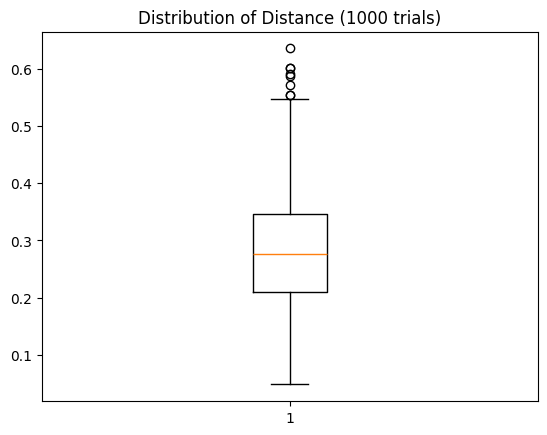

In [191]:
plt.boxplot(metrics)
plt.title("Distribution of Distance (1000 trials)")

Text(0, 0.5, 'CDF')

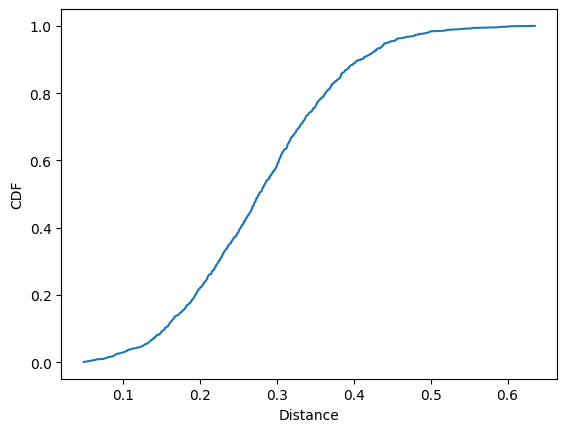

In [192]:
x = np.sort(metrics)
y = np.arange(1, len(x)+1) / len(x)

plt.plot(x, y)
plt.xlabel("Distance")
plt.ylabel("CDF")

In [193]:
SIM_DATA_PATH = dir / "data" / "sim_data_256.joblib"
SIM_DATA_PATH

WindowsPath('D:/CodingHenry/research_MBKM/data/sim_data_256.joblib')

In [194]:
sim_data = joblib.load(SIM_DATA_PATH)
sim_data

{'window_size': 256,
 'config': {'mean': 'zero', 'p': 1, 'q': 1, 'burn': 500},
 'sim_data': array([[-2.55560705e-03, -5.66225664e-04, -3.02228525e-04, ...,
          5.97432481e-03,  5.84060441e-04,  3.64529123e-03],
        [ 4.47763370e-03,  8.44963820e-03, -3.04722878e-03, ...,
         -8.30843952e-03,  1.84847183e-02, -1.21368972e-02],
        [ 5.04845292e-03,  4.47749316e-03,  4.60068867e-03, ...,
          1.47843791e-03, -3.54440937e-03, -5.46978476e-03],
        ...,
        [ 1.79513699e-03,  2.05970795e-03, -9.63646695e-04, ...,
          7.85340034e-03,  2.48024800e-03,  4.10670941e-03],
        [ 1.55818871e-02, -4.37128084e-05,  6.80299650e-04, ...,
          1.32176072e-03,  6.20959652e-03,  2.55586895e-04],
        [-3.38714433e-03,  6.55177055e-04,  2.43574677e-03, ...,
         -4.82698329e-04,  5.46065051e-03,  8.03269441e-03]],
       shape=(18, 256))}

In [195]:
sim_data_returns = sim_data["sim_data"]

In [196]:
# baseline
split = len(sim_data_returns) // 2

garch_A = sim_data_returns[:split]
garch_B = sim_data_returns[split:]

len(garch_A), len(garch_B)

(9, 9)

In [197]:
arch_A = compute_arch(garch_A)
arch_B = compute_arch(garch_B)

In [198]:
rho_A = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_A]
rho_B = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_B]

W_baseline = stats.wasserstein_distance(rho_A, rho_B)

In [ ]:
print("norm vs t")
print("Wassertein baseline : ", W_baseline)
print("Wassertein emp vs syn mean : ", metrics.mean())
print("Wassertein emp vs syn std : ", metrics.std())
print("Difference in baseline variability scale : ", metrics.mean() / W_baseline)

norm vs t
Wassertein baseline :  0.07421559298542972
Wassertein emp vs syn mean :  0.18375759449018772
Wassertein emp vs syn std :  0.09163639797758932
Difference in baseline variability scale :  2.475997119988837


In [199]:
print("t vs t")
print("Wassertein baseline : ", W_baseline)
print("Wassertein emp vs syn mean : ", metrics.mean())
print("Wassertein emp vs syn std : ", metrics.std())
print("Difference in baseline variability scale : ", metrics.mean() / W_baseline)

t vs t
Wassertein baseline :  0.07421559298542972
Wassertein emp vs syn mean :  0.2800862970096928
Wassertein emp vs syn std :  0.09917044470727623
Difference in baseline variability scale :  3.7739548488776524


In [ ]:
print("norm vs norm")
print("Wassertein baseline : ", W_baseline)
print("Wassertein emp vs syn mean : ", metrics.mean())
print("Wassertein emp vs syn std : ", metrics.std())
print("Difference in baseline variability scale : ", metrics.mean() / W_baseline)

norm vs norm
Wassertein baseline :  0.011921744004434983
Wassertein emp vs syn mean :  0.18747907826944826
Wassertein emp vs syn std :  0.09612730606660316
Difference in baseline variability scale :  15.725809764050005


In [139]:
print("t vs norm")
print("Wassertein baseline : ", W_baseline)
print("Wassertein emp vs syn mean : ", metrics.mean())
print("Wassertein emp vs syn std : ", metrics.std())
print("Difference in baseline variability scale : ", metrics.mean() / W_baseline)

t vs norm
Wassertein baseline :  0.011921744004434983
Wassertein emp vs syn mean :  0.27887881216073435
Wassertein emp vs syn std :  0.09942591409869349
Difference in baseline variability scale :  23.392450975041


### ARCH residuals diagnostics

In [200]:
def ljung_box_diagnostics(models, lags=20):
    n = len(models)

    rej = np.zeros((n, lags))
    pvals = np.zeros((n, lags))

    rej_sq = np.zeros((n, lags))
    pvals_sq = np.zeros((n, lags))

    for i, res in enumerate(models):

        std_resid = res.std_resid
        std_resid_sq = std_resid ** 2
        
        lb = sm.stats.acorr_ljungbox(std_resid, lags=lags, return_df=True)
        lb_sq = sm.stats.acorr_ljungbox(std_resid_sq, lags=lags, return_df=True)

        pvals[i, :] = lb["lb_pvalue"].values
        rej[i, :] = (lb["lb_pvalue"].values < 0.05).astype(int)

        pvals_sq[i, :] = lb_sq["lb_pvalue"].values
        rej_sq[i, :] = (lb_sq["lb_pvalue"].values < 0.05).astype(int)

    return rej, pvals, rej_sq, pvals_sq

In [201]:
def compare_ljung_box_arch_resampled(arch_emp, arch_syn, lags=20, n_iter=500, seed=42):
    rng = np.random.default_rng(seed)

    print("\n================ LJUNG-BOX COMPARISON (RESAMPLED) ================\n")

    print(">>> EMPIRICAL DATA")
    rej_e, p_e, rej_sq_e, p_sq_e = ljung_box_diagnostics(arch_emp, lags=lags)

    emp_lag = rej_e.mean(axis=0)
    emp_global = rej_e.mean()

    emp_sq_lag = rej_sq_e.mean(axis=0)
    emp_sq_global = rej_sq_e.mean()

    print("Standardized Residuals")
    print("Lag-wise rejection rate:", emp_lag)
    print("GLOBAL rejection rate   :", emp_global)
    print("Avg p-values           :", p_e.mean(axis=0))

    print("\nSquared Standardized Residuals")
    print("Lag-wise rejection rate:", emp_sq_lag)
    print("GLOBAL rejection rate   :", emp_sq_global)
    print("Avg p-values           :", p_sq_e.mean(axis=0))

    print("\n------------------------------------------------------\n")

    print(">>> SYNTHETIC DATA (RESAMPLED)")

    syn_lag_dist = []
    syn_sq_lag_dist = []
    syn_global = []
    syn_sq_global = []

    for _ in range(n_iter):
        syn_subset = rng.choice(arch_syn, size=len(arch_emp), replace=False)

        rej_s, p_s, rej_sq_s, p_sq_s = ljung_box_diagnostics(syn_subset, lags=lags)

        syn_lag_dist.append(rej_s.mean(axis=0))        
        syn_sq_lag_dist.append(rej_sq_s.mean(axis=0)) 
        syn_global.append(rej_s.mean())
        syn_sq_global.append(rej_sq_s.mean())

    syn_lag_dist = np.array(syn_lag_dist)
    syn_sq_lag_dist = np.array(syn_sq_lag_dist)

    syn_lag_mean = syn_lag_dist.mean(axis=0)
    syn_lag_std  = syn_lag_dist.std(axis=0)

    syn_sq_lag_mean = syn_sq_lag_dist.mean(axis=0)
    syn_sq_lag_std  = syn_sq_lag_dist.std(axis=0)

    print("Standardized Residuals")
    print("Lag-wise rejection rate (mean):", syn_lag_mean)
    print("Lag-wise rejection rate (std) :", syn_lag_std)
    print("GLOBAL rejection rate         :", np.mean(syn_global), "±", np.std(syn_global))

    print("\nSquared Standardized Residuals")
    print("Lag-wise rejection rate (mean):", syn_sq_lag_mean)
    print("Lag-wise rejection rate (std) :", syn_sq_lag_std)
    print("GLOBAL rejection rate         :", np.mean(syn_sq_global), "±", np.std(syn_sq_global))

    print("\n======================================================\n")

In [202]:
compare_ljung_box_arch_resampled(arch_emp, arch_syn)


================ LJUNG-BOX COMPARISON (RESAMPLED) ================

>>> EMPIRICAL DATA
Standardized Residuals
Lag-wise rejection rate: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.         0.
 0.         0.        ]
GLOBAL rejection rate   : 0.03888888888888889
Avg p-values           : [0.49174818 0.57269191 0.61914187 0.59143657 0.54965832 0.58133011
 0.58476532 0.55132246 0.50994829 0.49305107 0.50696907 0.5326237
 0.53647407 0.52710801 0.50880891 0.51339517 0.50992816 0.51661507
 0.55317816 0.56498909]

Squared Standardized Residuals
Lag-wise rejection rate: [0.         0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111]
GLOBAL rejection rate   : 0.10555555555555556
Avg p-values           : [0.3668

In [203]:
def resampled_distribution_diagnostics(arch_emp, arch_syn, n_iter=500, seed=42):
    rng = np.random.default_rng(seed)

    t_emp, n_emp, delta_emp = compute_aic_log_likelihood_stdresid(arch_emp)

    syn_t_list = []
    syn_n_list = []
    syn_delta_all = []

    for _ in range(n_iter):
        syn_subset = rng.choice(arch_syn, size=len(arch_emp), replace=False)

        t_syn, n_syn, delta_syn = compute_aic_log_likelihood_stdresid(syn_subset)

        syn_t_list.append(t_syn)
        syn_n_list.append(n_syn)
        syn_delta_all.extend(delta_syn)

    return {
        "emp_t": t_emp,
        "emp_n": n_emp,
        "emp_delta": np.array(delta_emp),

        "syn_t_dist": np.array(syn_t_list),
        "syn_n_dist": np.array(syn_n_list),
        "syn_delta": np.array(syn_delta_all),
    }

In [204]:
res_diag = resampled_distribution_diagnostics(arch_emp, arch_syn)

In [205]:
def print_distribution_diagnostics(results):

    print("\n================ DISTRIBUTION DIAGNOSTICS (STANDARDIZED RESIDUALS) ================\n")

    print(">>> EMPIRICAL DATA")
    print("Student-t wins :", results["emp_t"])
    print("Normal wins    :", results["emp_n"])
    print("Avg AIC diff   :", results["emp_delta"].mean())

    print("\n>>> SYNTHETIC DATA (RESAMPLED)")
    print("Student-t wins (avg):", results["syn_t_dist"].mean(), "±", results["syn_t_dist"].std())
    print("Normal wins    (avg):", results["syn_n_dist"].mean(), "±", results["syn_n_dist"].std())
    print("Avg AIC diff        :", results["syn_delta"].mean(), "±", results["syn_delta"].std())

    print("\n====================================================================================\n")

In [206]:
print_distribution_diagnostics(res_diag)


================ DISTRIBUTION DIAGNOSTICS (STANDARDIZED RESIDUALS) ================

>>> EMPIRICAL DATA
Student-t wins : 8
Normal wins    : 1
Avg AIC diff   : 17.474504683429977

>>> SYNTHETIC DATA (RESAMPLED)
Student-t wins (avg): 8.742 ± 0.5054067668719919
Normal wins    (avg): 0.258 ± 0.5054067668719919
Avg AIC diff        : 24.368816098920014 ± 17.184411303736134


